Leer archivo

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style='whitegrid')

df = pd.read_csv(r"C:\Users\andre\OneDrive\cosas de la universidad\Uniandes\VIII\Analitica comp\Proyecto\proyecto1-secop-agencia-logistica\02-ingenieria-datos\secop_ii_agencia_logistica_features_p3.csv")
df['fecha_de_firma'] = pd.to_datetime(df['fecha_de_firma'], errors='coerce')

print(df.shape)

(8051, 96)


Serie temporal anual

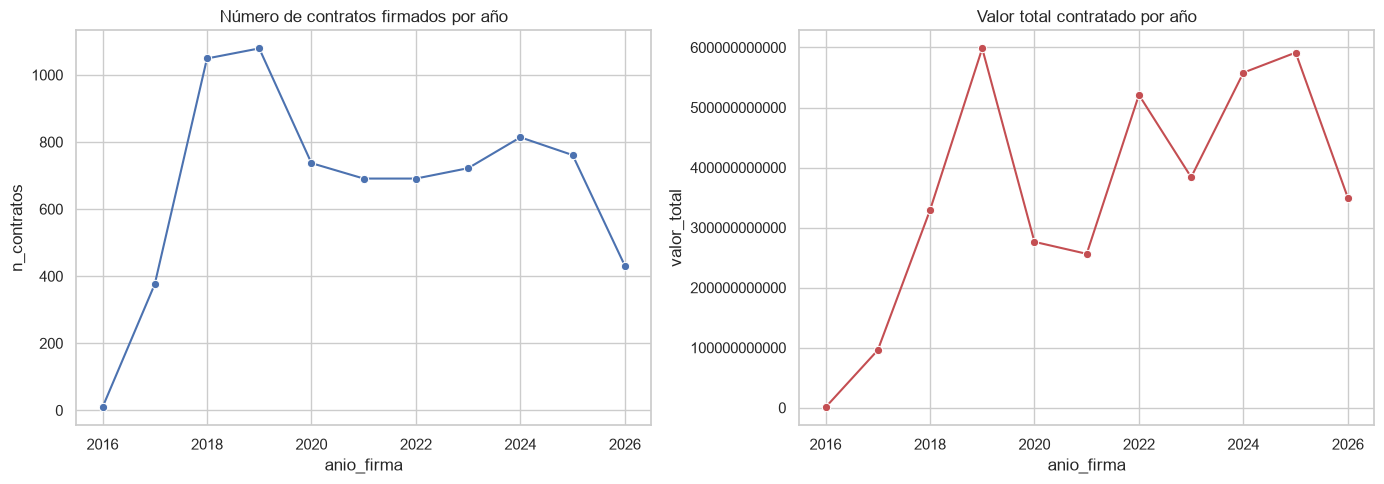

,anio_firma,n_contratos,valor_total
0,2016,9,6.880196e+08
1,2017,376,9.583462e+10
2,2018,1049,3.288999e+11
3,2019,1079,5.984102e+11
4,2020,737,2.762815e+11
5,2021,691,2.562981e+11
6,2022,691,5.209862e+11
7,2023,722,3.839399e+11
8,2024,814,5.580542e+11
9,2025,761,5.914494e+11


In [4]:
serie_anual = df.dropna(subset=['anio_firma']).groupby('anio_firma').agg(
    n_contratos=('valor_del_contrato', 'size'),
    valor_total=('valor_contrato_capped', 'sum')
).reset_index()
serie_anual['anio_firma'] = serie_anual['anio_firma'].astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=serie_anual, x='anio_firma', y='n_contratos', marker='o', ax=axes[0])
axes[0].set_title('Número de contratos firmados por año')

sns.lineplot(data=serie_anual, x='anio_firma', y='valor_total', marker='o', ax=axes[1], color='#C44E52')
axes[1].set_title('Valor total contratado por año')
axes[1].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()
serie_anual

serie mensual


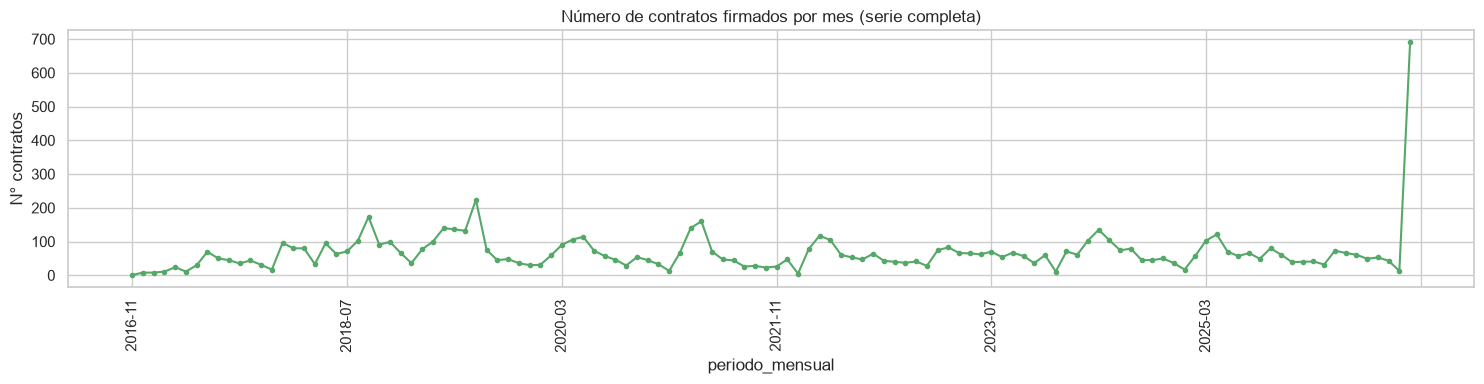

In [5]:
serie_mensual = df.dropna(subset=['periodo_mensual']).groupby('periodo_mensual').size()

plt.figure(figsize=(15, 4))
serie_mensual.plot(kind='line', marker='.', color='#55A868')
plt.title('Número de contratos firmados por mes (serie completa)')
plt.ylabel('N° contratos')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Patron estacional agregado

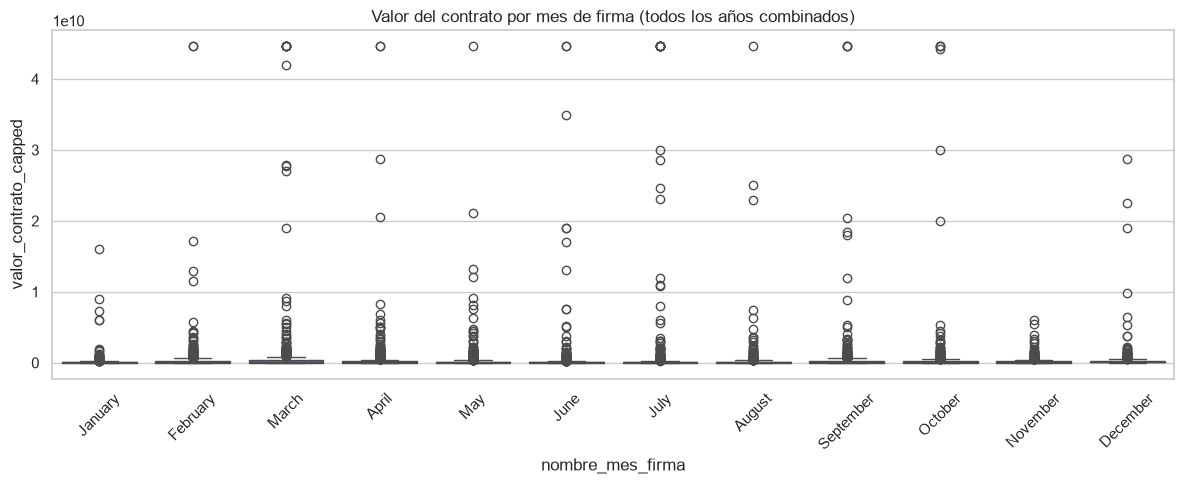

In [6]:
orden_meses = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

plt.figure(figsize=(12, 5))
sns.boxplot(x='nombre_mes_firma', y='valor_contrato_capped', data=df, order=orden_meses)
plt.title('Valor del contrato por mes de firma (todos los años combinados)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

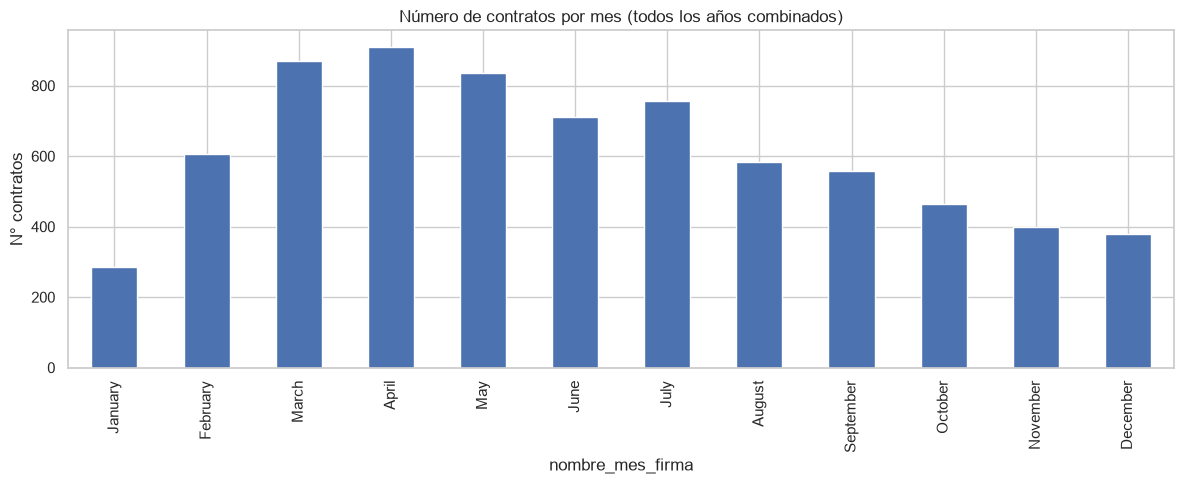

In [7]:
conteo_por_mes = df.groupby('nombre_mes_firma').size().reindex(orden_meses)

plt.figure(figsize=(12, 5))
conteo_por_mes.plot(kind='bar', color='#4C72B0')
plt.title('Número de contratos por mes (todos los años combinados)')
plt.ylabel('N° contratos')
plt.tight_layout()
plt.show()